In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [9]:
X_train['Age'].isnull().sum()

np.int64(148)

In [10]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([28.  , 36.  ,  4.  , 58.  , 21.  , 32.  , 42.  , 16.  , 65.  ,
       35.  , 36.  , 18.  , 39.  , 32.  , 35.  , 34.  , 32.  ,  4.  ,
       22.  , 47.  , 48.  ,  4.  , 24.  , 16.  , 26.  , 22.  , 19.  ,
       22.  , 44.  , 24.  , 59.  , 24.  , 22.  , 20.  ,  8.  , 21.  ,
       19.  , 32.  , 23.5 , 44.  , 33.  , 45.  , 16.  , 20.  , 25.  ,
       51.  , 26.  , 18.  , 27.  , 29.  , 27.  , 30.  , 36.  , 18.  ,
       29.  , 28.5 ,  9.  , 42.  , 30.  , 19.  , 21.  ,  2.  , 10.  ,
       48.  , 21.  ,  9.  , 46.  , 13.  , 24.  , 19.  , 63.  , 45.  ,
       21.  , 39.  , 14.  , 32.  , 27.  , 38.  , 25.  , 16.  , 24.  ,
       42.  , 16.  , 37.  , 34.  , 32.  , 42.  ,  2.  , 60.  , 19.  ,
       28.  , 45.  , 50.  , 59.  , 45.  , 20.  ,  4.  , 26.  , 25.  ,
       35.  ,  0.75, 31.  ,  1.  , 44.  , 29.  , 30.  , 21.  , 29.  ,
       28.  ,  0.42, 43.  , 27.  , 28.  , 18.  , 24.  , 31.  , 18.  ,
       30.  , 27.  , 38.  , 36.  , 61.  , 34.  , 27.  , 36.  , 39.  ,
       31.  , 28.  ,

In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_1385/3090101260.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_1385/3090101260.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are settin

In [12]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,NaN
493,71.0,49.5042,71.0
527,NaN,221.7792,NaN


/tmp/ipykernel_1385/2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/tmp/ipykernel_1385/2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)


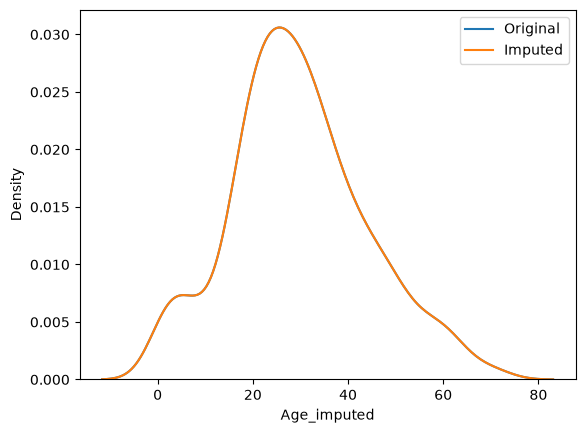

In [13]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [14]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.34951339046142


In [15]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.512440
Age,71.512440,204.349513,204.349513
Age_imputed,71.512440,204.349513,204.349513


<Axes: >

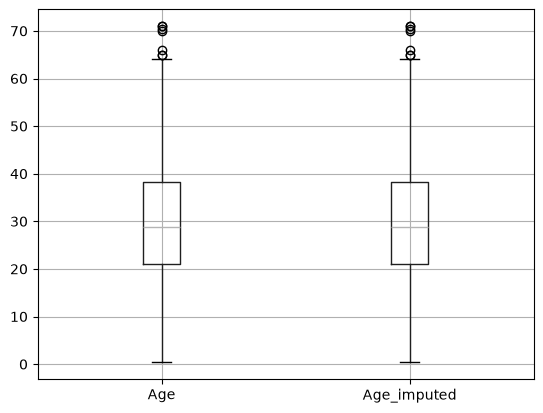

In [16]:
X_train[['Age', 'Age_imputed']].boxplot()

# If you wanna fix random value for particular input features during production(deployment):

In [17]:
for index, observation in X_train[X_train['Age'].isnull()].iterrows():

    sampled_value = X_train['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )

    X_train.loc[index, 'Age'] = sampled_value.iloc[0]

In [18]:
sampled_value

294    24.0
Name: Age, dtype: float64

# Running imputation twice:

In [19]:
X_train1 = X_train.copy()

for index, observation in X_train1[X_train1['Age'].isnull()].iterrows():
    sampled_value = X_train1['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )
    X_train1.loc[index, 'Age'] = sampled_value.iloc[0]

In [20]:
X_train2 = X_train.copy()

for index, observation in X_train2[X_train2['Age'].isnull()].iterrows():
    sampled_value = X_train2['Age'].dropna().sample(
        1,
        random_state=int(observation['Fare'])
    )
    X_train2.loc[index, 'Age'] = sampled_value.iloc[0]

In [21]:
(X_train1['Age'] == X_train2['Age']).all()
# That proves every missing value received the same sampled age in both runs

np.True_

# Method 2: Check one passenger

In [22]:
Fare = 71.83

In [23]:
X_train['Age'].dropna().sample(1, random_state=71)

503    37.0
Name: Age, dtype: float64

In [24]:
X_train['Age'].dropna().sample(1, random_state=71)# Getting same output after running it again.

503    37.0
Name: Age, dtype: float64

# Method 3: Print the mapping

In [25]:
for index, observation in X_train[X_train['Age'].isnull()].iterrows():

    seed = int(observation['Fare'])

    sampled_value = X_train['Age'].dropna().sample(
        1,
        random_state=seed
    )

    print(f"Index = {index}")
    print(f"Fare = {observation['Fare']}")
    print(f"Seed = {seed}")
    print(f"Sampled Age = {sampled_value.iloc[0]}")
    print("-"*30)

# Option 1: Use the row index as the seed (Simple & Recommended)

In [26]:
X_train_imputed = X_train.copy()

for index, observation in X_train_imputed[X_train_imputed['Age'].isnull()].iterrows():

    sampled_value = X_train_imputed['Age'].dropna().sample(
        1,
        random_state=index
    )

    X_train_imputed.loc[index, 'Age'] = sampled_value.iloc[0]

# Option 2: Use multiple columns to create the seed More Robust

In [27]:
import hashlib

X_train_imputed = X_train.copy()

for index, observation in X_train_imputed[X_train_imputed['Age'].isnull()].iterrows():

    seed_string = f"{index}_{observation['Fare']}_{observation['Pclass']}_{observation['Sex']}"

    seed = int(hashlib.md5(seed_string.encode()).hexdigest(), 16) % (2**32)

    sampled_value = X_train_imputed['Age'].dropna().sample(
        1,
        random_state=seed
    )

    X_train_imputed.loc[index, 'Age'] = sampled_value.iloc[0]

# Option 3: Use NumPy's random number generator (Modern Approach)

In [28]:
import numpy as np

X_train_imputed = X_train.copy()

ages = X_train_imputed['Age'].dropna()

for index in X_train_imputed[X_train_imputed['Age'].isnull()].index:

    rng = np.random.default_rng(seed=index)

    sampled_age = rng.choice(ages)

    X_train_imputed.loc[index, 'Age'] = sampled_age

# Professional Approach: 
Instead of writing a for loop every time, we create a custom transformer that can be plugged directly into a Pipeline.

In [37]:
#X_train.drop(columns=['Age_imputed'], inplace=True)
X_test.drop(columns=['Age_imputed'], inplace=True)

KeyError: "['Age_imputed'] not found in axis"

In [30]:
# Step1: Import libraries:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

In [31]:
# Step2: Create the Random Sample Imputer class
class RandomSampleImputer(BaseEstimator, TransformerMixin):
    
    def __init__(self, variable):
        self.variable = variable
        
    # Learn from training data:
    def fit(self, X, y=None):
        
            self.non_missing_value = X[self.variable].dropna()
            return self
    
    # Apply random sample imputation:
    def transform(self, X):
        
        X = X.copy()
        missing_index= X[X[self.variable].isnull()].index    
        
        sampled_values = self.non_missing_value.sample(
            len(missing_index),
            replace = True,
            random_state=42
        )
        
        sampled_values.index = missing_index
        
        X.loc[missing_index, self.variable] = sampled_values
        
        return X
        
                
        

In [32]:
# Step3: Create the Imputer
age_imputer = RandomSampleImputer(variable='Age')

In [33]:
# Step4: Fit on training data
age_imputer.fit(X_train)

,variable,'Age'


In [34]:
# Step5: Transform training data
X_train= age_imputer.transform(X_train)

In [35]:
# Step 6: Transform test data
X_test = age_imputer.transform(X_test)

In [38]:
# Use it inside a Pipeline:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe= Pipeline([
    ('age_imputer', RandomSampleImputer(variable='Age')),
    ('model',LogisticRegression())
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X_train.isnull().sum()

Age     0
Fare    0
dtype: int64

In [ ]:
age_imputer = RandomSampleImputer(variable='Age')

age_imputer.fit(X_train)

X_train2 = age_imputer.transform(X_train)

print(X_train['Age'].isnull().sum())
print(X_train2['Age'].isnull().sum())

0
0


# Working with New Dataset:

In [39]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [40]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [41]:
X = data
y = data['SalePrice']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [43]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [44]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
995,NaN,TA,121600,TA,NaN
807,TA,TA,223500,TA,TA
1146,TA,TA,180000,TA,TA
150,NaN,TA,122000,TA,NaN
1296,NaN,TA,155000,TA,NaN


In [46]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_1385/2056505658.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp/ipykernel_1385/2056505658.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate o

In [48]:
temp= pd.concat([
    X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ], axis= 1)
temp.columns = ['original', ' imputed']
temp

,original,imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [49]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.338945
TA,0.412439,0.282828
Fa,0.040917,0.028058
Po,0.027823,0.019080
Ex,0.024550,0.016835


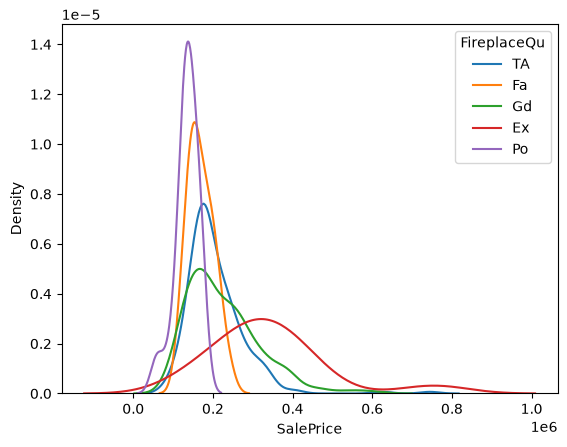

In [57]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu']== category]['SalePrice'] ,label= category)
plt.legend(title='FireplaceQu')    
plt.show() 
  

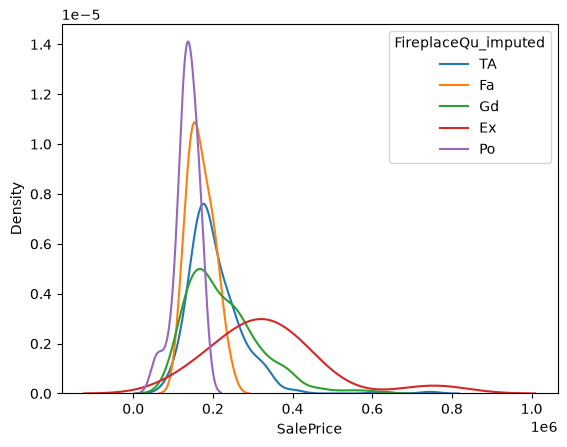

In [58]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed']== category]['SalePrice'] ,label= category)
plt.legend(title='FireplaceQu_imputed')    
plt.show() 